In [137]:
# Ячейка № 1

# подключение используемых библиотек

# подключение библиотеки numpy
import numpy as np

# подключение метода solve_ivp из библиотеки scipy.integrate
from scipy.integrate import solve_ivp

# подключение библиотек и методов,
# используемых для визуализации
# результатов моделирования
import matplotlib.pyplot as plt


In [138]:
# Ячейка № 2

# расчет и визуализация потенциала
# электрического поля зарядов Q1 и Q2

# задание координат радиуса-вектора заряда Q1
X1 = 0
Y1 = 0

# задание координат радиуса-вектора заряда Q2
X2 = 2.1
Y2 = 0

# задание значения электрического заряда Q1
Q1 = 2

# задание значения электрического заряда Q2
Q2 = 1

# вычисление отношения зарядов Q2 к Q1
K = Q2 / Q1


# задание функции, возвращающей
# значения электростатического потенциала
# системы двух электрических зарядов Q1, Q2
def U2q(x, y):
    # определение числа узлов
    # координатной сетки по оси OX
    Nx = len(x)

    # определение числа узлов
    # координатной сетки по оси OY
    Ny = len(y)

    # инициализация массива z[Nx,Ny],
    # используемого для хранения значений
    # электростатического потенциала,
    # вычисленного в узлах координатной сетки
    z = np.zeros([Nx, Ny])

    # вычисление значений потенциала,
    # создаваемого системой зарядов Q1, Q2
    # в узлах координатной сетки
    for i in range(Nx):
        for j in range(Ny):
            R1 = np.sqrt((x[i, j] - X1) ** 2 + (y[i, j] - Y1) ** 2)
            R2 = np.sqrt((x[i, j] - X2) ** 2 + (y[i, j] - Y2) ** 2)
            z[i, j] = -1 / R1 - K / R2

    return z


# задание числа узлов сетки,
# в узлах которой вычисляются
# значения потенциала,
# создаваемого системой
# электрических зарядов Q1, Q2
Nd = 56

# задание минимальных и максимальных значений
# координат узлов  используемой сетки
Xmin = X1 - 1
Xmax = X2 + 1
Ymin = Y1 - 1
Ymax = Y2 + 1

# вычисление шага координатной сетки по оси абсцисс
dx = (Xmax - Xmin) / (Nd - 1)

# вычисление шага координатной сетки по оси ординат
dy = (Ymax - Ymin) / (Nd - 1)

x = np.arange(Xmin, Xmax, dx)

y = np.arange(Ymin, Ymax, dy)

# вычисление значений электростатического потенциала,
# создаваемого системой электрических зарядов,
# в узлах выбранной сетки
[y2, x2] = np.meshgrid(y, x)
M = U2q(x2, y2)


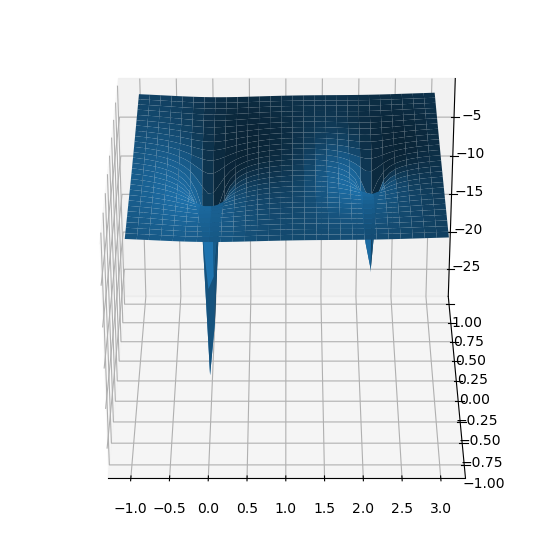

In [139]:
# Ячейка № 3

# визуализация электростатического потенциала,
# создаваемого системой двух электрических зарядов Q1, Q2
# в виде 3D-поверхности

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(projection="3d")
surf = ax.plot_surface(x2, y2, M)
ax.view_init(azim=-90, elev=30)

plt.show()

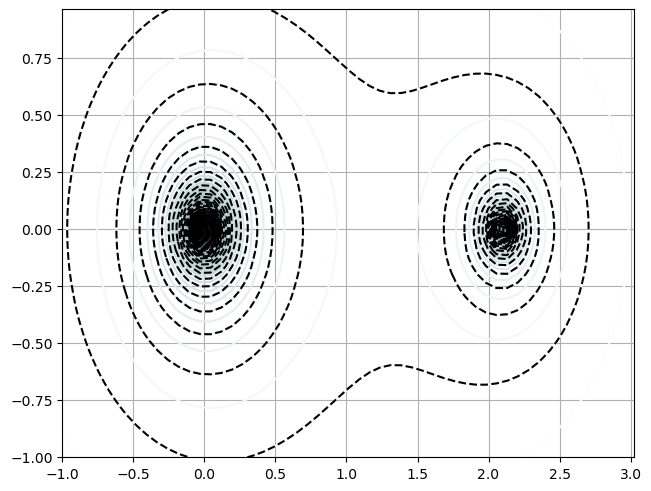

In [140]:
# Ячейка № 4

# визуализация карты линий уровня
# электрического потенциала в плоскости XOY

fig, ax2 = plt.subplots(layout="constrained")
CS = ax2.contour(x2, y2, M, levels=99, cmap=plt.cm.bone)
CS2 = ax2.contour(CS, levels=CS.levels[::2], colors="black")
plt.grid(True)

plt.show()

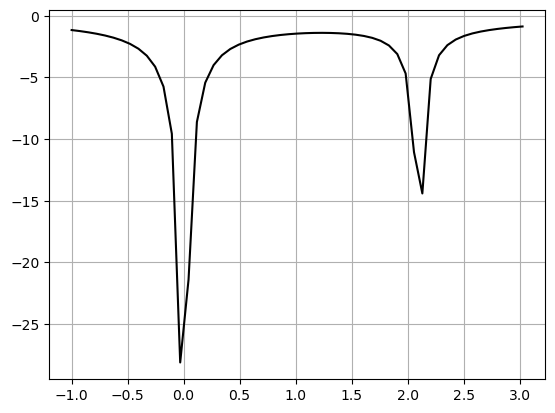

In [141]:
# Ячейка № 5

# визуализация сечения электростатического потенциала
# плоскостью х = 0

ax = fig.add_subplot()
plt.plot(x[:], M[:, 28], color="black")
plt.grid(True)

plt.show()

In [ ]:
# Ячейка № 6

# задание функции, возвращающей значения
# первых производных в (6.102)
def M2q(t, z):
    # вычисление отношения значений электрических зарядов
    K = Q2 / Q1

    # инициализация массива, используемого для хранения
    # значений первых производных в (6.102)
    dz = np.zeros(4)

    R1 = np.sqrt((z[0] - X1) ** 2 + (z[2] - Y1) ** 2)
    R2 = np.sqrt((z[0] - X2) ** 2 + (z[2] - Y2) ** 2)
    dz[0] = z[1]
    dz[1] = -4 * np.pi**2 * (z[0] - X1) / R1**3 - 4 * np.pi**2 * K * (z[0] - X2) / R2**3
    dz[2] = z[3]
    dz[3] = -4 * np.pi**2 * (z[2] - Y1) / R1**3 - 4 * np.pi**2 * K * (z[2] - Y2) / R2**3

    return dz

In [ ]:
# Ячейка № 7

# задание начальных значений координат заряда q
X0 = -1
Y0 = 0

# задание кинетической энергии заряда q
dW = 0.5

# вычисление значения модуля начальной скорости
# заряда q
V = np.pi * np.sqrt(8 * dW)

# задание начальных значений скорости заряда q
Vx = 0
Vy = V

# вычисление начального значения полной энергии заряда q
[x0, y0] = np.meshgrid(X0, Y0)
E0 = U2q(x0, y0) + dW
E0 = E0[0, 0]

# задание шаг интегрирования и длительности временного интервала,
# на котором вычисляется численное решение СДУ (6.102)
dt = 2 * 10**-4
Tmax = 5


# вычисление численного решения СДУ (6.102)
Solv = solve_ivp(M2q, [0, Tmax], [X0, Vx, Y0, Vy], max_step=dt)

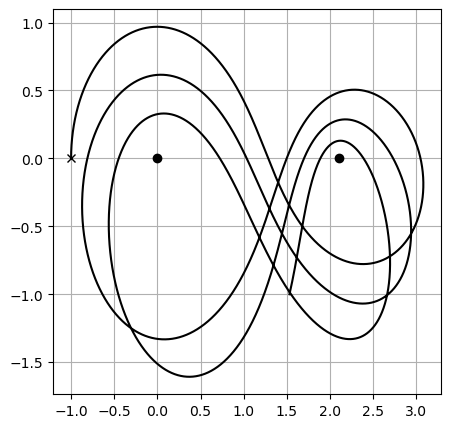

In [ ]:
# Ячейка № 8

# визуализация траектории движения заряда q,
# начального положения заряда,
# положений зарядов Q1, Q2
fig = plt.figure(figsize=(11, 5))

ax = fig.add_subplot(121)
plt.plot(Solv.y[0, :], Solv.y[2, :], color="black")
plt.plot(X0, Y0, "x", color="black")
plt.plot(X1, Y1, "o", color="black")
plt.plot(X2, Y2, "o", color="black")
plt.grid(True)

# визуализация зависимости погрешности
# выполнения закона сохранения энергии
# ax = fig.add_subplot(122)
# plt.plot(Solv.t[:], np.abs(E[:] - E0) / E0 * 100, color="black")
# plt.grid(True)

plt.show()